In [9]:
import numpy as np
from scipy.stats import norm  # the normal distribution
import matplotlib.pyplot as plt

S0 = 297
K = 300
r = 0.04
sigma = 0.226
T = 1

In [10]:
def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T)) #ln(S0/K)
    d2 = d1 - sigma*np.sqrt(T)

    call = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2) #N((d1), area under bell curve
    return call

def bs_put_price(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    put = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)
    return put

In [12]:
bs_call = bs_call_price(S0, K, r, sigma, T)
bs_put = bs_put_price(S0, K, r, sigma, T)

print("Black-Scholes call:", round(bs_call, 2))
print("Black-Scholes put: ", round(bs_put, 2))
print()
print("Your MC call was:   30.44")
print("Your Mc put was:    21.84")

Black-Scholes call: 30.94
Black-Scholes put:  22.17

Your MC call was:   30.44
Your Mc put was:    21.84


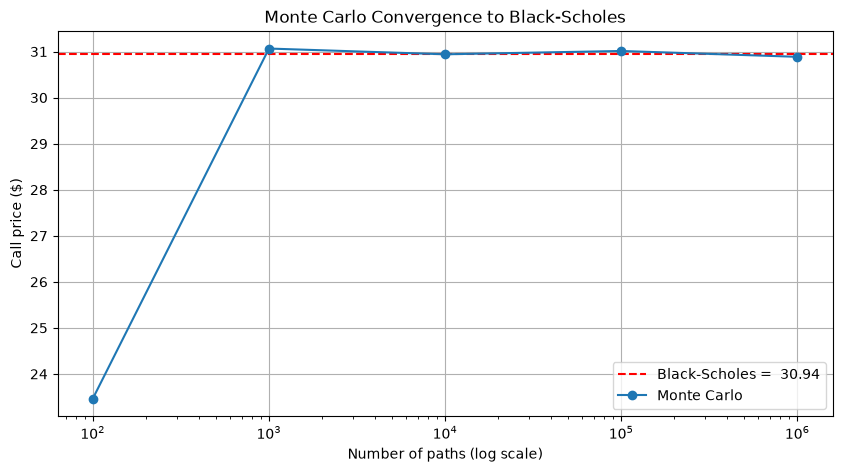

In [16]:
def mc_call_price(S0, K, r, sigma, T, n_paths, seed=42):
    np.random.seed(seed)
    Z = np.random.standard_normal(n_paths)
    S_T = S0 * np.exp((r - sigma**2/2)*T + sigma*np.sqrt(T)*Z)
    payoffs = np.maximum(S_T - K, 0)
    return np.exp(-r*T) * np.mean(payoffs)

path_counts = [100, 1000, 10000, 100000, 1000000]
mc_prices = [mc_call_price(S0, K, r, sigma, T, n) for n in path_counts]

plt.figure(figsize=(10, 5))
plt.axhline(bs_call, color="red", linestyle="--", label=f"Black-Scholes = {bs_call: .2f}")
plt.plot(path_counts, mc_prices, "o-", label="Monte Carlo")
plt.xscale("log")
plt.xlabel("Number of paths (log scale)")
plt.ylabel("Call price ($)")
plt.title("Monte Carlo Convergence to Black-Scholes")
plt.legend()
plt.grid(True)
plt.show()
